In [2]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import yfinance as yf

In [3]:
#Black_Scholes_OneDimension
class blackscholesmodel:
    def __init__(self,S,X,t,r,sigma):
        self.S = S
        self.X = X
        self.t = t
        self.r = r
        self.sigma = sigma
    def d1(self):
        return (np.log(self.S / self.X) + (self.r + 0.5 * (self.sigma ** 2)) * self.t) / (self.sigma * np.sqrt(self.t))
    def d2(self):
        return self.d1() - (self.sigma * np.sqrt(self.t))
    def call_price(self):
        return (self.S * norm.cdf(self.d1(), 0, 1) - self.X * np.exp(-self.r * self.t) * norm.cdf(self.d2(), 0, 1))
    def put_price(self):
        return (self.X * np.exp(-self.r * self.t) * norm.cdf(-self.d2(), 0, 1) - self.S * norm.cdf(-self.d1(), 0, 1))

In [4]:
call_price = blackscholesmodel(100,110,1,0.05,0.25).call_price()
print(call_price)

8.026384693853352


Call: $5.9885
Put:  $8.3960
IV from $5.50 call: 23.27%


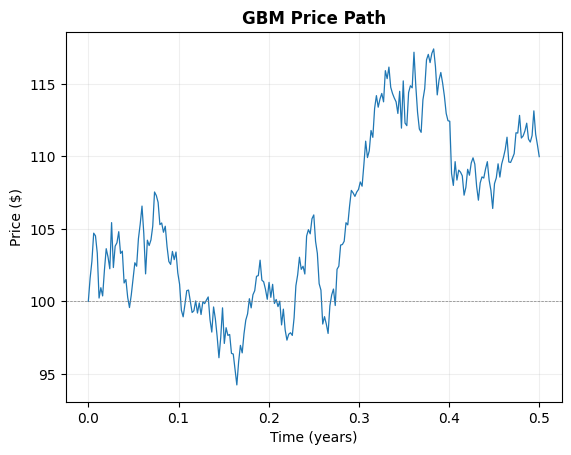

In [5]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt


class blackscholesmodel:
    def __init__(self, S, X, t, r, sigma):
        self.S = S
        self.X = X
        self.t = t
        self.r = r
        self.sigma = sigma

    def d1(self):
        return (np.log(self.S / self.X) + (self.r + 0.5 * (self.sigma ** 2)) * self.t) / (self.sigma * np.sqrt(self.t))

    def d2(self):
        return self.d1() - (self.sigma * np.sqrt(self.t))

    def call_price(self):
        return (self.S * norm.cdf(self.d1(), 0, 1) - self.X * np.exp(-self.r * self.t) * norm.cdf(self.d2(), 0, 1))

    def put_price(self):
        return (self.X * np.exp(-self.r * self.t) * norm.cdf(-self.d2(), 0, 1) - self.S * norm.cdf(-self.d1(), 0, 1))

    def greeks(self, option_type="call"):
        d1, d2 = self.d1(), self.d2()
        sqrt_t = np.sqrt(self.t)
        gamma = norm.pdf(d1) / (self.S * self.sigma * sqrt_t)
        vega  = self.S * norm.pdf(d1) * sqrt_t / 100
        if option_type == "call":
            delta = norm.cdf(d1)
            theta = (-(self.S * self.sigma * norm.pdf(d1)) / (2 * sqrt_t)
                     - self.r * self.X * np.exp(-self.r * self.t) * norm.cdf(d2)) / 365
            rho   = self.X * self.t * np.exp(-self.r * self.t) * norm.cdf(d2) / 100
        else:
            delta = norm.cdf(d1) - 1
            theta = (-(self.S * self.sigma * norm.pdf(d1)) / (2 * sqrt_t)
                     + self.r * self.X * np.exp(-self.r * self.t) * norm.cdf(-d2)) / 365
            rho   = -self.X * self.t * np.exp(-self.r * self.t) * norm.cdf(-d2) / 100
        return {"delta": delta, "gamma": gamma, "theta": theta, "vega": vega, "rho": rho}

    def implied_vol(self, market_price, option_type="call", tol=1e-8, max_iter=200):
        sig = 0.3
        for _ in range(max_iter):
            temp = blackscholesmodel(self.S, self.X, self.t, self.r, sig)
            price = temp.call_price() if option_type == "call" else temp.put_price()
            vega_raw = self.S * norm.pdf(temp.d1()) * np.sqrt(self.t)
            if abs(vega_raw) < 1e-14:
                break
            diff = price - market_price
            if abs(diff) < tol:
                return sig
            sig -= diff / vega_raw
            sig = max(0.0001, min(sig, 10.0))
        return sig

    def simulate(self, N=252, num_paths=1, seed=None):
        """GBM simulation: returns (t_array, price_paths)"""
        if seed is not None:
            np.random.seed(seed)
        dt = self.t / N
        t = np.linspace(0, self.t, N + 1)
        dW = np.random.normal(0, np.sqrt(dt), size=(num_paths, N))
        log_S = np.zeros((num_paths, N + 1))
        log_S[:, 1:] = np.cumsum((self.r - 0.5 * self.sigma**2) * dt + self.sigma * dW, axis=1)
        S = self.S * np.exp(log_S)
        return t, S

    def plot_gbm(self, N=252, num_paths=1, seed=None):
        t, S = self.simulate(N, num_paths, seed)
        for i in range(num_paths):
            plt.plot(t, S[i], linewidth=0.9)
        plt.axhline(self.S, color="gray", linewidth=0.5, linestyle="--")
        plt.title("GBM Price Path", fontweight="bold")
        plt.xlabel("Time (years)")
        plt.ylabel("Price ($)")
        plt.grid(alpha=0.2)
        plt.show()


# â”€â”€ Usage â”€â”€

model = blackscholesmodel(S=100, X=105, t=0.5, r=0.05, sigma=0.25)

print(f"Call: ${model.call_price():.4f}")
print(f"Put:  ${model.put_price():.4f}")
print(f"IV from $5.50 call: {model.implied_vol(5.50, 'call')*100:.2f}%")

model.plot_gbm()

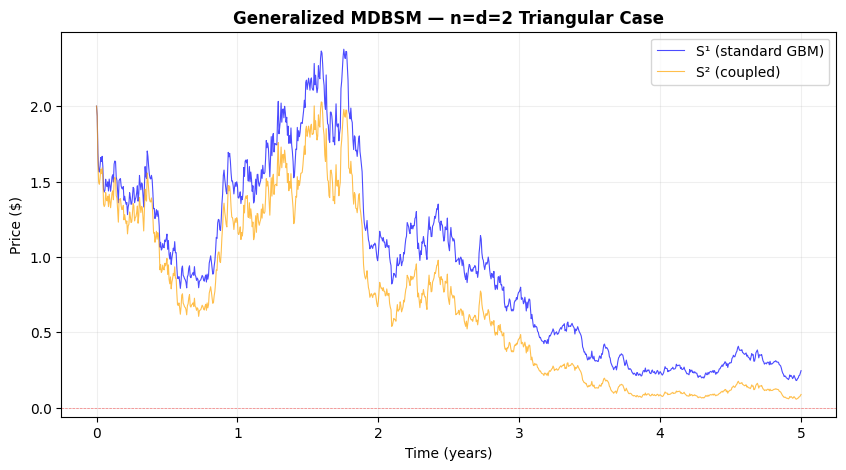

In [6]:
import numpy as np
import matplotlib.pyplot as plt


class MDBSM:
    def __init__(self, x1_0, x2_0, mu1, mu2, b1, b2, b21_1, b21_2, T, N=1000):
        self.x1_0  = x1_0
        self.x2_0  = x2_0
        self.mu1   = mu1
        self.mu2   = mu2
        self.b1    = b1
        self.b2    = b2
        self.b21_1 = b21_1
        self.b21_2 = b21_2
        self.T     = T
        self.N     = N
        self.dt    = T / N
        self.t     = np.linspace(0, T, N + 1)

    def _check_nonarbitrage(self):
        """det[[b1, b2], [b21_1, b21_2]] != 0"""
        det = self.b1 * self.b21_2 - self.b2 * self.b21_1
        if abs(det) < 1e-12:
            print("WARNING: volatility matrix is singular â€” arbitrage possible")
        return det

    def simulate(self):
        dt = self.dt
        sqrt_dt = np.sqrt(dt)

        dW1 = np.random.normal(0, sqrt_dt, self.N)
        dW2 = np.random.normal(0, sqrt_dt, self.N)

        # S1: exact GBM solution
        sigma_sq = self.b1**2 + self.b2**2
        cum_W1 = np.concatenate([[0], np.cumsum(dW1)])
        cum_W2 = np.concatenate([[0], np.cumsum(dW2)])

        S1 = self.x1_0 * np.exp(
            (self.mu1 - 0.5 * sigma_sq) * self.t
            + self.b1 * cum_W1
            + self.b2 * cum_W2
        )

        S2 = np.zeros(self.N + 1)
        S2[0] = self.x2_0
        stopped = False

        for i in range(self.N):
            if stopped:
                S2[i + 1] = 0
                continue

            drift = self.mu2 * S2[i]
            diff1 = (self.b21_1 * S1[i] + self.b1 * S2[i]) * dW1[i]
            diff2 = (self.b21_2 * S1[i] + self.b2 * S2[i]) * dW2[i]

            S2[i + 1] = S2[i] + drift * dt + diff1 + diff2 #S2

            if S2[i + 1] <= 0:
                S2[i + 1] = 0
                stopped = True

        return S1, S2

    def plot(self, num_paths=1):
        self._check_nonarbitrage()

        plt.figure(figsize=(10, 5))

        for _ in range(num_paths):
            S1, S2 = self.simulate()
            plt.plot(self.t, S1, linewidth=0.8, alpha=0.7, color="blue")
            plt.plot(self.t, S2, linewidth=0.8, alpha=0.7, color="orange")

        plt.axhline(0, color="red", linewidth=0.5, linestyle="--", alpha=0.5)
        plt.legend(["SÂ¹ (standard GBM)", "SÂ² (coupled)"])
        plt.title("Generalized MDBSM â€” n=d=2 Triangular Case", fontweight="bold")
        plt.xlabel("Time (years)")
        plt.ylabel("Price ($)")
        plt.grid(alpha=0.2)
        plt.show()


model = MDBSM(
    x1_0  = 2,     # initial price stock 1
    x2_0  = 2,      # initial price stock 2
    mu1   = 0.08,    # drift stock 1
    mu2   = 0.06,    # drift stock 2
    b1    = 0.40,    # shared vol component 1
    b2    = 0.50,    # shared vol component 2
    b21_1 = 0.10,    # cross-coupling W1
    b21_2 = 0.05,    # cross-coupling W2
    T     = 5.0,
    N     = 1000
)

model.plot(num_paths=1)

In [8]:
stock_data = pd.read_csv("stock_dat.csv", parse_dates=["date"], index_col="date")

print(stock_data.head())


                ibm     dell
date                        
2002-01-02  60.3688  27.2421
2002-01-03  61.4420  28.7577
2002-01-04  62.4059  29.3125
2002-01-07  61.6358  29.3422
2002-01-08  61.9588  29.3620


In [12]:
B1 = np.array([[ 0.2445,  0.2774],
               [ 0.4155, -1.3032]])

B2 = np.array([[-1.3611,  6.2997],
               [ 0.4044, -1.1423]])

print(B1)
print(B2)

[[ 0.2445  0.2774]
 [ 0.4155 -1.3032]]
[[-1.3611  6.2997]
 [ 0.4044 -1.1423]]


In [14]:
# Monte Carlo pricing of European calls on IBM using the 2-asset EBS model
# SDE: dS_t = r*S_t dt + (B1 @ S_t)*dW1 + (B2 @ S_t)*dW2  (Euler-Maruyama)

np.random.seed(42)

S0_IBM  = stock_data['ibm'].iloc[-1]
S0_DELL = stock_data['dell'].iloc[-1]
S0      = np.array([S0_IBM, S0_DELL])
r       = 0.05    # annual risk-free rate
M       = 10**6   # number of paths
L       = 100     # discretisation steps

In [ ]:
def mc_european_surface(S0, B1, B2, r, maturities_days, strikes_pct, M=10**6, L=100):
    call_surface = np.zeros((len(maturities_days), len(strikes_pct)))
    put_surface  = np.zeros((len(maturities_days), len(strikes_pct)))

    B1f = B1.astype(np.float32)
    B2f = B2.astype(np.float32)

    for i, T_days in enumerate(maturities_days):
        T       = T_days / 365.0
        dt      = T / L
        sqrt_dt = np.sqrt(dt)
        disc    = np.exp(-r * T)

        S = np.tile(S0.astype(np.float32), (M, 1))   # (M, 2)

        for _ in range(L):
            dW1 = np.random.normal(0.0, sqrt_dt, M).astype(np.float32)
            dW2 = np.random.normal(0.0, sqrt_dt, M).astype(np.float32)
            v1  = S @ B1f.T                            # (M, 2)
            v2  = S @ B2f.T                            # (M, 2)
            S   = S + r * S * dt + v1 * dW1[:, None] + v2 * dW2[:, None]
            np.maximum(S, 0.0, out=S)

        S_IBM_T = S[:, 0]

        for j, K_pct in enumerate(strikes_pct):
            K = float(S0[0]) * K_pct / 100.0
            call_payoff = np.maximum(S_IBM_T - K, 0.0)
            put_payoff  = np.maximum(K - S_IBM_T, 0.0)
            call_surface[i, j] = disc * call_payoff.mean() / S0[0] * 100.0
            put_surface[i, j]  = disc * put_payoff.mean()  / S0[0] * 100.0

        print(f"  T = {T_days:4d} days | call ATM ~ {call_surface[i, len(strikes_pct)//2]:.2f}% of spot")

    return call_surface, put_surface


S0_IBM = $51.17   S0_DELL = $26.89
Running Monte Carlo — this may take a few minutes...
  T =   10 days | call ATM ~ 8.01% of spot
  T =   30 days | call ATM ~ 16.88% of spot
  T =   60 days | call ATM ~ 27.28% of spot
  T =   90 days | call ATM ~ 36.56% of spot
  T =  120 days | call ATM ~ 44.70% of spot
  T =  180 days | call ATM ~ 58.02% of spot
  T =  252 days | call ATM ~ 70.05% of spot
  T =  360 days | call ATM ~ 84.08% of spot
  T =  480 days | call ATM ~ 95.43% of spot
  T =  600 days | call ATM ~ 105.15% of spot
  T =  720 days | call ATM ~ 114.83% of spot
Done.


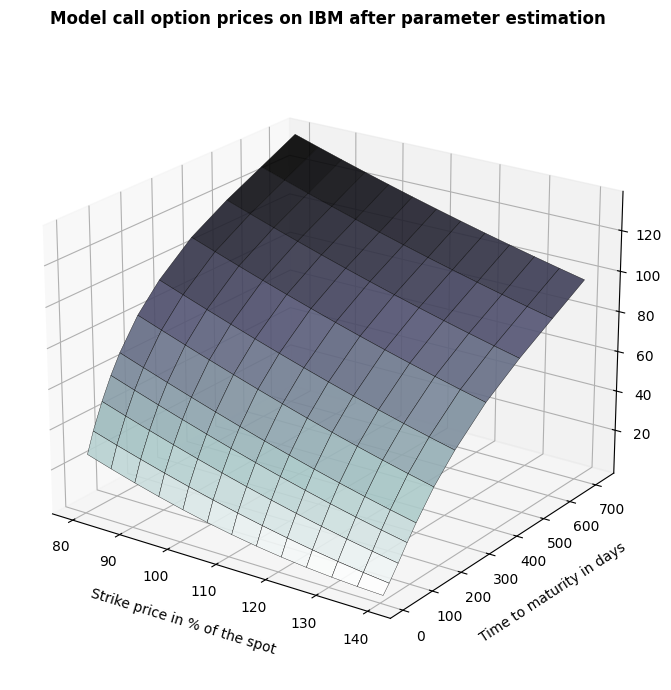

In [15]:
# ── Grid ──────────────────────────────────────────────────────────────────────
strikes_pct     = np.linspace(80, 140, 13)
maturities_days = np.array([10, 30, 60, 90, 120, 180, 252, 360, 480, 600, 720])

print(f"S0_IBM = ${S0_IBM:.2f}   S0_DELL = ${S0_DELL:.2f}")
print("Running Monte Carlo — this may take a few minutes...")
call_surf, put_surf = mc_european_surface(S0, B1, B2, r, maturities_days, strikes_pct, M=M, L=L)
print("Done.")

# ── 3-D figure (call) ─────────────────────────────────────────────────────────
K_grid, T_grid = np.meshgrid(strikes_pct, maturities_days)

fig = plt.figure(figsize=(11, 7))
ax  = fig.add_subplot(111, projection="3d")

ax.plot_surface(K_grid, T_grid, call_surf,
                cmap="bone_r", edgecolor="k", linewidth=0.25, alpha=0.9)

ax.set_xlabel("Strike price in % of the spot", labelpad=10, fontsize=10)
ax.set_ylabel("Time to maturity in days",       labelpad=10, fontsize=10)
ax.set_zlabel("Call price in % of the spot",    labelpad=8,  fontsize=10)
ax.set_title("Model call option prices on IBM after parameter estimation",
             fontweight="bold", pad=14)
ax.view_init(elev=22, azim=-55)

plt.tight_layout()
plt.show()

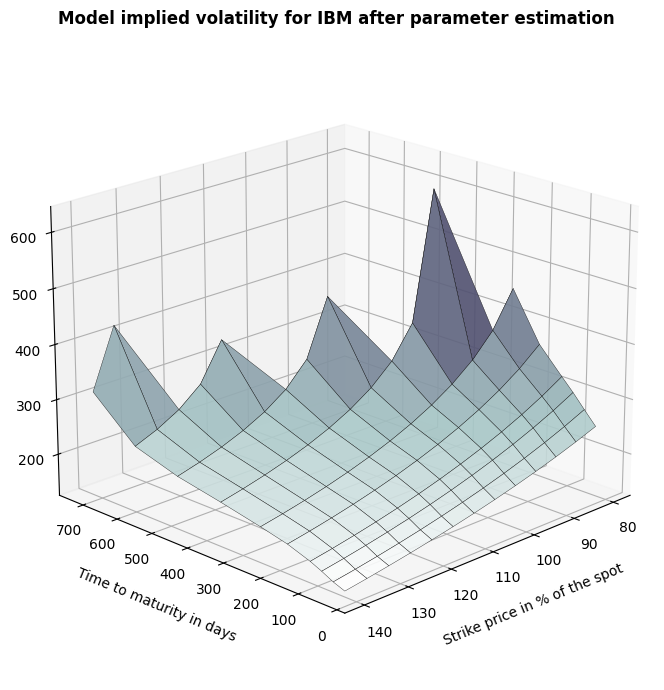

In [16]:
# Implied volatility surface for IBM
# Invert Black-Scholes call formula on the MC prices from call_surf

from scipy.optimize import brentq
from scipy.stats import norm as _norm

def _bs_call(S, K, T, r, sigma):
    if T <= 0 or sigma <= 1e-9:
        return max(S - K * np.exp(-r * T), 0.0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * _norm.cdf(d1) - K * np.exp(-r * T) * _norm.cdf(d2)

def implied_vol(S, K, T, r, mkt_price, lo=1e-4, hi=10.0, tol=1e-7):
    intrinsic = max(S - K * np.exp(-r * T), 0.0)
    if mkt_price <= intrinsic + 1e-8:
        return np.nan
    try:
        f = lambda sig: _bs_call(S, K, T, r, sig) - mkt_price
        if f(lo) > 0 or f(hi) < 0:
            return np.nan
        return brentq(f, lo, hi, xtol=tol)
    except Exception:
        return np.nan

# Use maturities >= 30 days (short maturities are numerically unstable for IV)
mat_mask   = maturities_days >= 30
iv_mats    = maturities_days[mat_mask]
iv_strikes = strikes_pct

iv_surf = np.full((len(iv_mats), len(iv_strikes)), np.nan)

for i, T_days in enumerate(iv_mats):
    T     = T_days / 365.0
    i_src = np.where(maturities_days == T_days)[0][0]
    for j, K_pct in enumerate(iv_strikes):
        K         = float(S0_IBM) * K_pct / 100.0
        mkt_price = call_surf[i_src, j] / 100.0 * float(S0_IBM)
        iv        = implied_vol(float(S0_IBM), K, T, r, mkt_price)
        iv_surf[i, j] = iv * 100.0 if iv is not None and not np.isnan(iv) else np.nan

# 3-D plot
K_grid_iv, T_grid_iv = np.meshgrid(iv_strikes, iv_mats)

fig = plt.figure(figsize=(11, 7))
ax  = fig.add_subplot(111, projection="3d")

ax.plot_surface(K_grid_iv, T_grid_iv, iv_surf,
                cmap="bone_r", edgecolor="k", linewidth=0.25, alpha=0.9)

ax.set_xlabel("Strike price in % of the spot", labelpad=10, fontsize=10)
ax.set_ylabel("Time to maturity in days",       labelpad=10, fontsize=10)
ax.set_zlabel("Volatility in %",                labelpad=8,  fontsize=10)
ax.set_title("Model implied volatility for IBM after parameter estimation",
             fontweight="bold", pad=14)
ax.invert_yaxis()
ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()